In [ ]:
# !which python
!python --version
!pip freeze > requirements.txt

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")
grid_data = pd.read_csv(data_dir / "PATH_Ref_62_CatchRing.csv")
# input_data, output_data

# Visualisation

In [ ]:
input_data.nunique()
# input_data.info()
input_data.head()
# input_data = input_data.loc[:, input_data.nunique() > 1]
# input_21 is degrees and should be converted to radians
# input_data.iloc[:, 21] = np.radians(input_data.iloc[:, 21])
# input_data.describe()
#input_20 is initial hair length
# input_14 is elevation angle is in degrees
# High 1 10
# Second High 11 3 9 2 4 6
# Third High 18 19 
input_data.nunique()
# Drop columns with only one unique value
# input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()
# input_data.head()
# Number of rows in input_data and output_data
# len(input_data), len(output_data)
grid_data.describe()
# grid_data.nunique()
output_data.describe()
# input_data.nunique()
# output_data.nunique() 

In [ ]:

import numpy as np
x_col = "x_begin1_hair"
y_col = "y_begin1_hair"
dx_col = "dx1_hair"
dy_col = "dy1_hair"

x_valsbegin = grid_data["x_begin1_hair"].to_numpy()
y_valsbegin = grid_data["y_begin1_hair"].to_numpy()

x_valsend = x_valsbegin - grid_data["dx1_hair"].to_numpy()
y_valsend = y_valsbegin - grid_data["dy1_hair"].to_numpy()

x_vals = np.sort(np.unique(np.concatenate([x_valsbegin, x_valsend])))
y_vals = np.sort(np.unique(np.concatenate([y_valsbegin, y_valsend])))

X, Y = np.meshgrid(x_vals, y_vals)
XYPos = np.stack((X, Y), axis=-1)

ny = len(y_vals)
nx = len(x_vals)

XYGridBegin = np.zeros((ny, nx), dtype=int)
XYGridEnd = np.zeros((ny, nx), dtype=int)
XYGridDXY = np.zeros((ny, nx, 2), dtype=float)

n = len(grid_data)
inputHairs = np.zeros((ny, nx), dtype=int)
for k in range(n):
    x = grid_data.loc[k, x_col]
    y = grid_data.loc[k, y_col]
    dx = grid_data.loc[k, dx_col]
    dy = grid_data.loc[k, dy_col]

    row = np.where(np.isclose(y_vals, y))[0][0]
    col = np.where(np.isclose(x_vals, x))[0][0]

    XYGridBegin[row, col] = 1
    XYGridDXY[row, col] = (dx, dy)

    x_end = x - dx
    y_end = y - dy

    row = np.where(np.isclose(y_vals, y_end))[0][0]
    col = np.where(np.isclose(x_vals, x_end))[0][0]

    XYGridEnd[row, col] = 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_min = grid_data[x_col].min()
y_min = grid_data[y_col].min()

x_max = (grid_data[x_col]).max()
y_max = (grid_data[y_col]).max()

common_extent = [x_min, x_max, y_min, y_max]

plt.figure()
plt.imshow(XYGridBegin, origin="lower", extent=common_extent, aspect="auto")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("XYGridBegin")
plt.show()

imgXYGridDXY = np.linalg.norm(XYGridDXY, axis=-1)

plt.figure()
plt.imshow(imgXYGridDXY, origin="lower", extent=common_extent, aspect="auto")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("XYGridDXY magnitude")
plt.show()

plt.figure()
plt.imshow(XYGridEnd, origin="lower", extent=common_extent, aspect="auto")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("XYGridEnd")
plt.show()

# Placing input_data in Grids
1) The output will be a collection of X "images" with 20 channels, grid size 62 by 31. 
2) X will be how many "training inputs" that are there

In [57]:

import numpy as np
# Input Data
x_col = "input_18"
y_col = "input_19"
channel_cols = [c for c in input_data.columns if c not in [x_col, y_col]]

x_vals = np.sort(input_data[x_col].unique())
y_vals = np.sort(input_data[y_col].unique())

nx = len(x_vals)
ny = len(y_vals)
n_channels = len(channel_cols)

points_per_image = nx * ny
n_images = len(input_data) // points_per_image

images = np.empty((n_images, ny, nx, n_channels), dtype=object)
images[:] = None

x_to_col = {x: i for i, x in enumerate(x_vals)}
y_to_row = {y: i for i, y in enumerate(y_vals)}

for img_i in range(n_images):
    df_img = input_data.iloc[
        img_i * points_per_image : (img_i + 1) * points_per_image
    ]

    for _, row in df_img.iterrows():
        r = y_to_row[row[y_col]]
        c = x_to_col[row[x_col]]

        images[img_i, r, c, :] = row[channel_cols].to_numpy(dtype=object)

print(images.shape)
print(channel_cols)

print("Created Input Data. Making Output Data next")
# Output Data
output_channel_cols = output_data.columns[:3].tolist()

outputs = np.full((n_images, ny, nx, 3), np.nan, dtype=float)

for img_i in range(n_images):
    df_in_img = input_data.iloc[
        img_i * points_per_image : (img_i + 1) * points_per_image
    ]

    df_out_img = output_data.iloc[
        img_i * points_per_image : (img_i + 1) * points_per_image
    ]

    for local_i, (_, row) in enumerate(df_in_img.iterrows()):
        r = y_to_row[row[y_col]]
        c = x_to_col[row[x_col]]

        outputs[img_i, r, c, 0] = int(df_out_img.iloc[local_i]["output_1"])    # binary
        outputs[img_i, r, c, 1] = int(df_out_img.iloc[local_i]["output_2"])    # integer
        outputs[img_i, r, c, 2] = float(df_out_img.iloc[local_i]["output_3"])  # float

print(outputs.shape)
print(output_channel_cols)

(21, 62, 31, 20)
['input_1', 'input_2', 'input_3', 'input_4', 'input_5', 'input_6', 'input_7', 'input_8', 'input_9', 'input_10', 'input_11', 'input_12', 'input_13', 'input_14', 'input_15', 'input_16', 'input_17', 'input_20', 'input_21', 'input_22']
Created Input Data. Making Output Data next
(21, 62, 31, 3)
['output_1', 'output_2', 'output_3']


# Visualising the Data

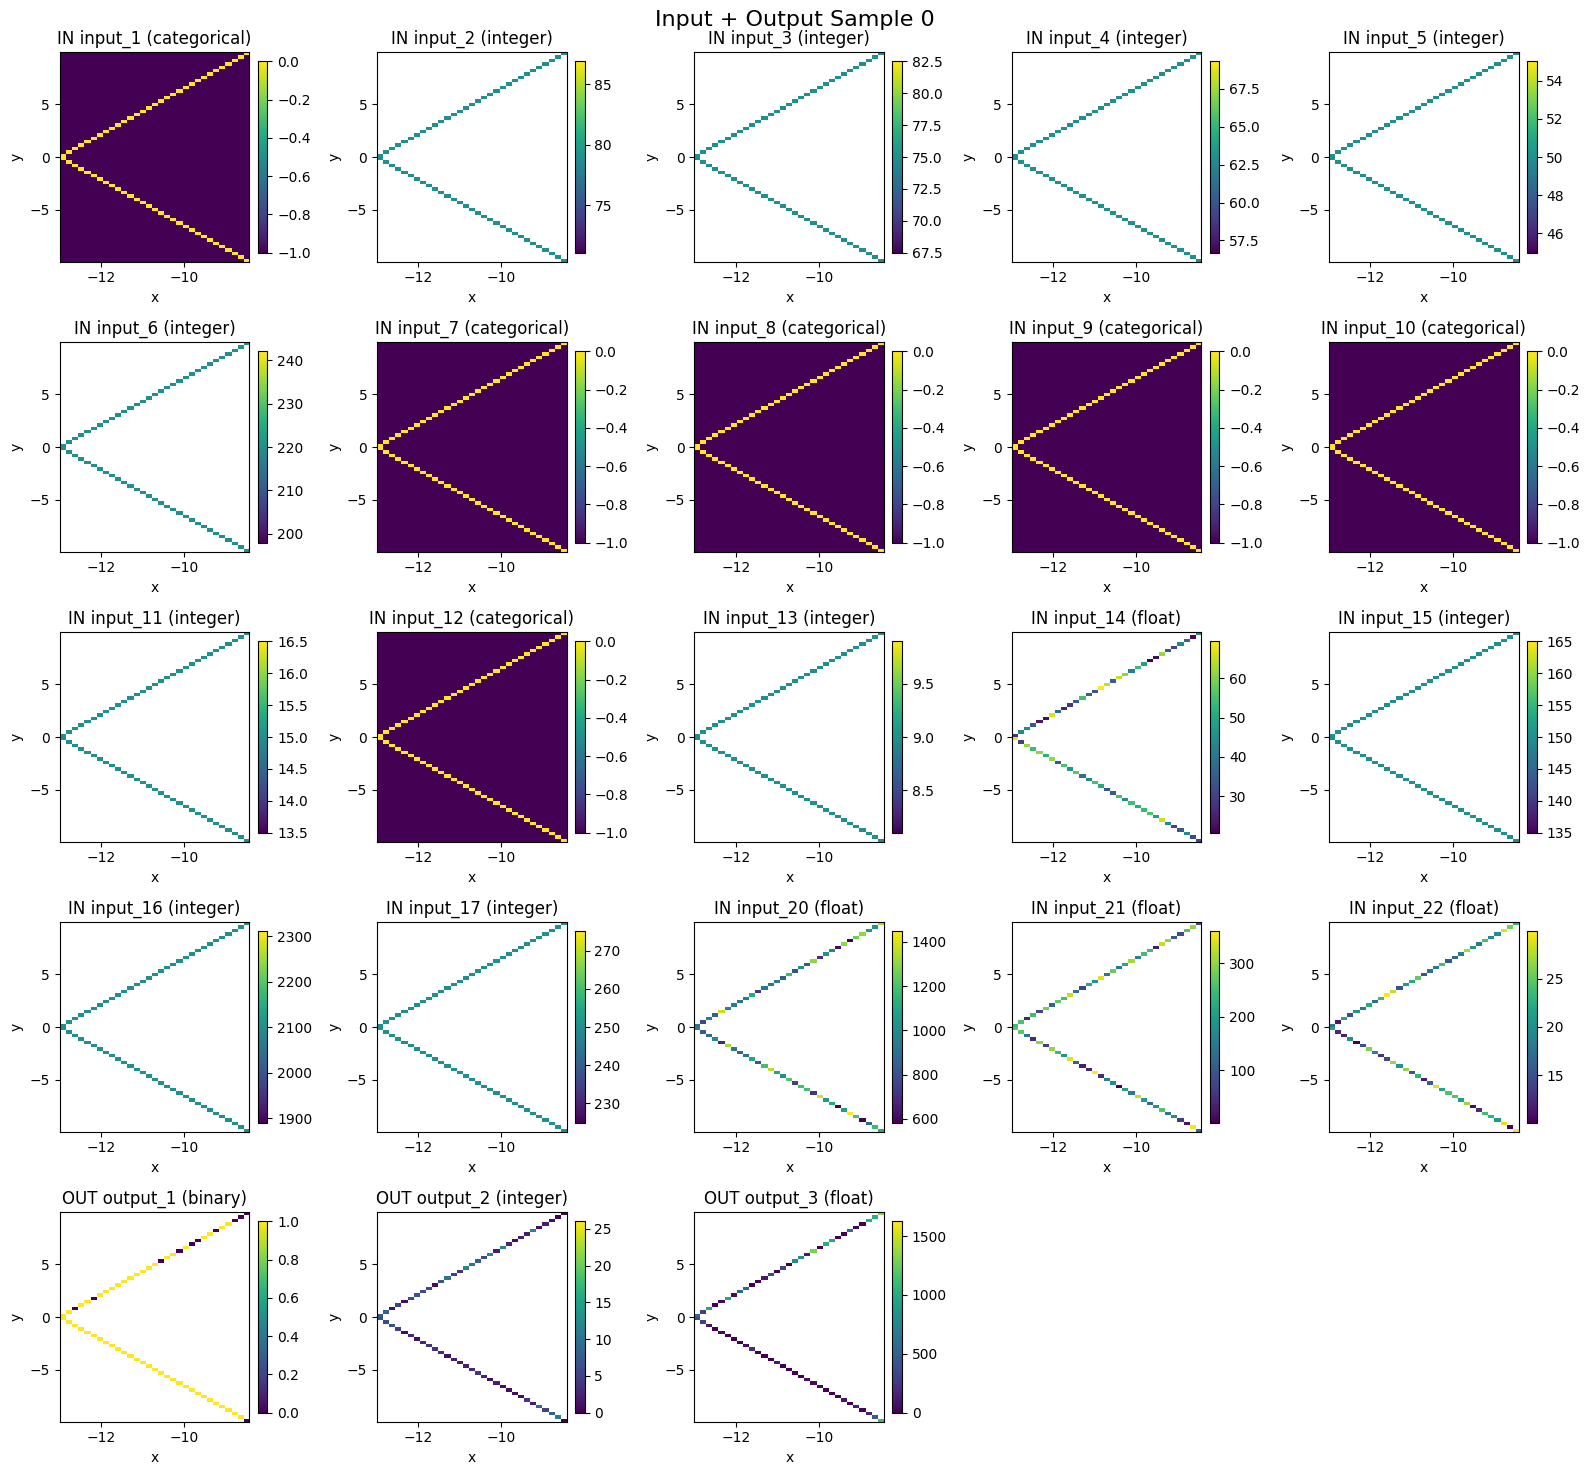

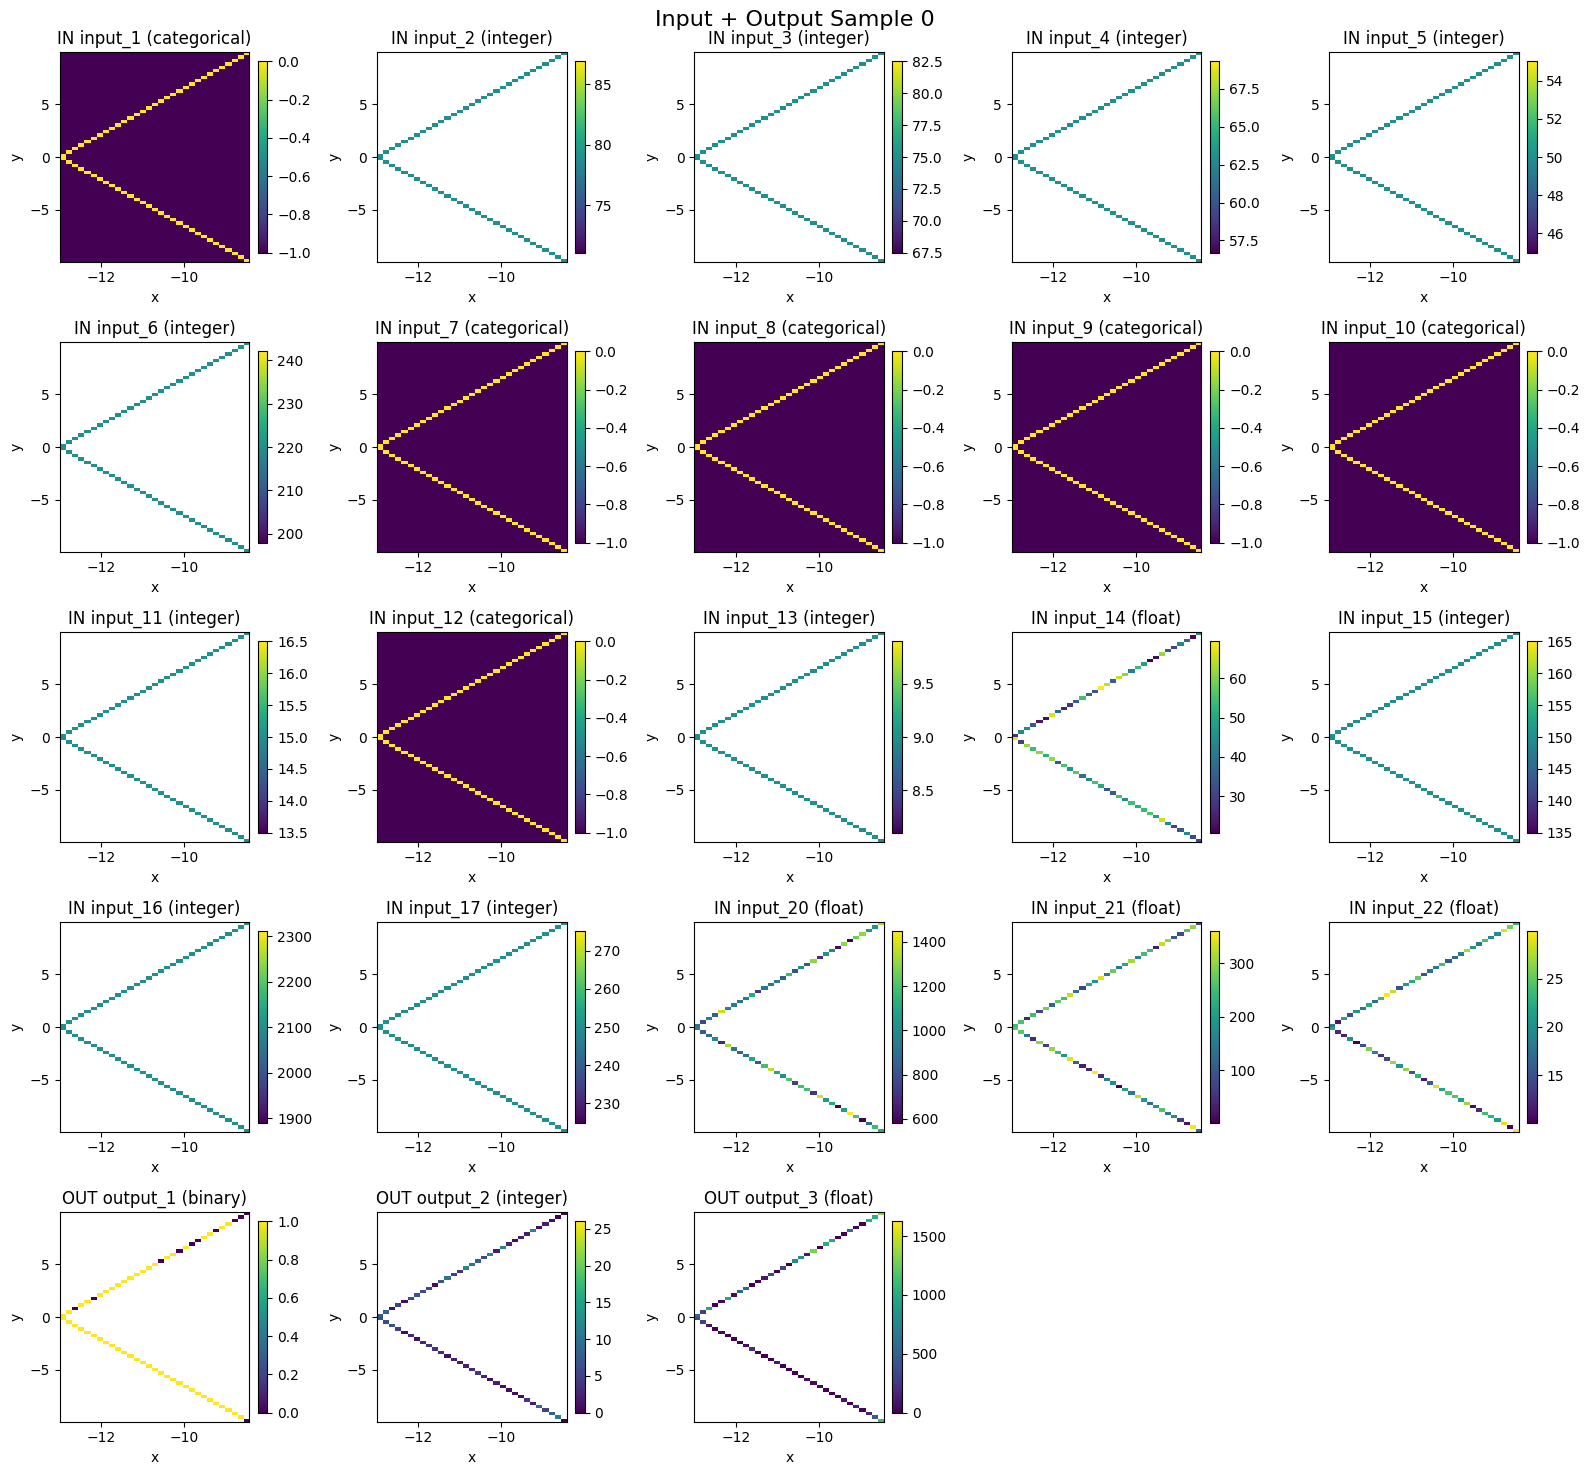

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def channel_to_image(A, colname):
    flat = A.ravel()

    categorical_inputs = [1, 7, 8, 9, 10, 12]
    integer_inputs = [2, 3, 4, 5, 6, 11, 13, 15, 16, 17]

    categorical_cols = [f"input_{i}" for i in categorical_inputs]
    integer_cols = [f"input_{i}" for i in integer_inputs]

    if colname in categorical_cols:
        codes, uniques = pd.factorize(flat)
        return codes.reshape(A.shape), "categorical"

    elif colname in integer_cols:
        numeric = pd.to_numeric(flat, errors="coerce")
        return np.asarray(numeric).reshape(A.shape), "integer"

    else:
        numeric = pd.to_numeric(flat, errors="coerce")
        return np.asarray(numeric).reshape(A.shape), "float"


def plot_input_output_sample(images, outputs, sample_idx, channel_cols, output_channel_cols):
    x_min = input_data[x_col].min()
    y_min = input_data[y_col].min()
    x_max = input_data[x_col].max()
    y_max = input_data[y_col].max()

    common_extent = [x_min, x_max, y_min, y_max]

    fig, axes = plt.subplots(5, 5, figsize=(16, 15))
    axes = axes.ravel()

    # 20 input channels
    for ch in range(20):
        colname = channel_cols[ch]
        A = images[sample_idx, :, :, ch]

        img, kind = channel_to_image(A, colname)

        ax = axes[ch]
        im = ax.imshow(
            img,
            origin="lower",
            aspect="auto",
            extent=common_extent
        )

        ax.set_title(f"IN {colname} ({kind})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 3 output channels
    output_vmins = np.nanmin(outputs, axis=(0, 1, 2))
    output_vmaxs = np.nanmax(outputs, axis=(0, 1, 2))
    for ch in range(3):
        colname = output_channel_cols[ch]
        A = outputs[sample_idx, :, :, ch]

        ax = axes[20 + ch]
        im = ax.imshow(
            A,
            origin="lower",
            aspect="auto",
            extent=common_extent,
            vmin=output_vmins[ch],
            vmax=output_vmaxs[ch]
        )

        if ch == 0:
            kind = "binary"
        elif ch == 1:
            kind = "integer"
        else:
            kind = "float"

        ax.set_title(f"OUT {colname} ({kind})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # hide empty plots
    for ax in axes[23:]:
        ax.axis("off")

    fig.suptitle(f"Input + Output Sample {sample_idx}", fontsize=16)
    plt.tight_layout()

    return fig
plot_input_output_sample(images, outputs, 0, channel_cols, output_channel_cols)

# Creating PDF file of Data

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
num_imgs = images.shape[0]

with PdfPages("data.pdf") as pdf:
    for i in range(num_imgs):
        fig = plot_input_output_sample(
            images,
            outputs,
            i,
            channel_cols,
            output_channel_cols
        )

        pdf.savefig(fig)
        plt.close(fig)
        print(f"Saved Image {i} of {num_imgs}")



Saved Image 0 of 21
Saved Image 1 of 21
Saved Image 2 of 21
Saved Image 3 of 21
Saved Image 4 of 21
Saved Image 5 of 21
Saved Image 6 of 21
Saved Image 7 of 21


# Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_input(
    input_data,
    encodingHigh=0,
    categoricalEncodingHighType="one-hot",
    encodingMed=0,
    categoricalEncodingMedType="one-hot",
    encodingLow=0,
    categoricalEncodingLowType="one-hot",
    convertToRadians=0
):
    df = input_data.copy()

    # If nothing is enabled, return unchanged
    if (
        encodingHigh == 0 and
        encodingMed == 0 and
        encodingLow == 0 and
        convertToRadians == 0
    ):
        return df

    # Helper function
    def encode_columns(df, cols, encoding_type):
        cols = [col for col in cols if col in df.columns]

        if len(cols) == 0:
            return df

        if encoding_type is None:
            encoding_type = "one-hot"

        encoding_type = encoding_type.lower()

        if encoding_type == "one-hot":
            df = pd.get_dummies(df, columns=cols)

        elif encoding_type == "label":
            le = LabelEncoder()
            for col in cols:
                df[col] = le.fit_transform(df[col].astype(str))

        return df

    # High group
    if encodingHigh != 0:
        high_cols = ["input_10"]
        df = encode_columns(df, high_cols, categoricalEncodingHighType)

    # Medium group
    if encodingMed != 0:
        med_cols = [
            "input_2", "input_3", "input_4",
            "input_6", "input_8","input_9", "input_11",
            "input_10"
        ]
        df = encode_columns(df, med_cols, categoricalEncodingMedType)

    # Low group
    if encodingLow != 0:
        low_cols = ["input_18", "input_19"]
        df = encode_columns(df, low_cols, categoricalEncodingLowType)

    # Convert angles to radians
    if convertToRadians != 0:
        for col in ["input_14", "input_21"]:
            if col in df.columns:
                df[col] = np.deg2rad(df[col])
    return df

# Train Test Split

In [ ]:
import numpy as np

def trainTestSplit(processedInput, output, Train=10, Test=3, seed=42):
    # Unique values of input_1
    unique_vals = processedInput["input_1"].unique()

    # Check count
    if len(unique_vals) != Train + Test:
        raise ValueError(
            f"Found {len(unique_vals)} unique values in input_1, "
            f"but Train + Test = {Train + Test}"
        )

    # Shuffle with seed
    rng = np.random.RandomState(seed)
    shuffled_vals = unique_vals.copy()
    rng.shuffle(shuffled_vals)

    # Split
    TrainVals = shuffled_vals[:Train]
    TestVals = shuffled_vals[Train:]

    # Create train and test sets
    input_train = processedInput[processedInput["input_1"].isin(TrainVals)].copy()
    input_test = processedInput[processedInput["input_1"].isin(TestVals)].copy()
    output_train = output[processedInput["input_1"].isin(TrainVals)].copy()
    output_test = output[processedInput["input_1"].isin(TestVals)].copy()

    # Drop input_1 after splitting
    input_train = input_train.drop(columns=["input_1"])
    input_test = input_test.drop(columns=["input_1"])

    return input_train, input_test,output_train,output_test, TrainVals, TestVals


input_data.nunique()
# Drop columns with only one unique value
input_data = input_data.loc[:, input_data.nunique() > 1]
input_data.nunique()

processed_input = preprocess_input(input_data, encodingHigh=1, categoricalEncodingHighType="one-hot", encodingMed=1, categoricalEncodingMedType="one-hot", encodingLow=1, categoricalEncodingLowType="one-hot", convertToRadians=1)
input_train, input_test,output_train,output_test, TrainVals, TestVals = trainTestSplit(processedInput=processed_input, output=output_data, Train=10, Test=3, seed=42)
input_train.head()


# TabPFN
Does not work. Licensed tool. Not paying for this.

In [ ]:
# from tabpfn import TabPFNClassifier, TabPFNRegressor

# # clf = TabPFNClassifier()
# # clf.fit(input_train, output_data)  # downloads checkpoint on first use
# # predictions = clf.predict(input_test)

# reg = TabPFNRegressor()
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# predictions = reg.predict(input_test)

# Tree Models Initialisation

In [ ]:
from sklearn.model_selection import train_test_split # Function to split data into training and testing sets
import numpy as np


from xgboost import XGBRegressor

def train_xgboost(X_train, y_train):
    model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    verbosity=2
)

    model.fit(X_train, y_train, verbose=True)
    return model

from lightgbm import LGBMRegressor
def train_lightgbm(X_train, y_train):
    model = LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    return model

from catboost import CatBoostRegressor
def train_catboost(X_train, y_train, categorical_columns=None):
    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=10
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_columns
    )

    return model

In [ ]:
output_data.head()

# Training on Output_1

In [ ]:
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_1"])
lgb_model = train_lightgbm(input_train, output_train["output_1"])
cat_model = train_catboost(input_train, output_train["output_1"])

# Testing

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_1"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_1")
    ax.set_ylabel("Predicted output_1")

plt.tight_layout()
plt.show()

# Training Output 2

In [ ]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_2"])
lgb_model = train_lightgbm(input_train, output_train["output_2"])
cat_model = train_catboost(input_train, output_train["output_2"])

# Testing Output 2

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_2"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_2")
    ax.set_ylabel("Predicted output_2")

plt.tight_layout()
plt.show()

# Training Output 3

In [ ]:
# Training on Output_1
# X_train = Xtrain[0]
# y_train = Ytrain[0]["output_1"]
# reg.fit(input_train, output_data)  # downloads checkpoint on first use
# input_train, input_test,output_train,output_test, TrainVals, TestVals 
xgb_model = train_xgboost(input_train, output_train["output_3"])
lgb_model = train_lightgbm(input_train, output_train["output_3"])
cat_model = train_catboost(input_train, output_train["output_3"])

# Testing Output 3

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
xgb_pred = xgb_model.predict(input_test)
lgb_pred = lgb_model.predict(input_test)
cat_pred = cat_model.predict(input_test)

y_true = output_test["output_3"].values

# Metrics
models = {
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}

r2_scores = []
mae_scores = []
rmse_scores = []

for name, pred in models.items():
    r2_scores.append(r2_score(y_true, pred))
    mae_scores.append(mean_absolute_error(y_true, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_true, pred)))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(models.keys(), r2_scores)
axes[0].set_title("R² Score")
axes[0].set_ylabel("Higher is better")

axes[1].bar(models.keys(), mae_scores)
axes[1].set_title("MAE")
axes[1].set_ylabel("Lower is better")

axes[2].bar(models.keys(), rmse_scores)
axes[2].set_title("RMSE")
axes[2].set_ylabel("Lower is better")

plt.tight_layout()
plt.show()


# Scatter plot: true vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_true, pred, alpha=0.7)

    # ideal line
    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_title(name)
    ax.set_xlabel("True output_3")
    ax.set_ylabel("Predicted output_3")

plt.tight_layout()
plt.show()

# Auto Gluon

In [ ]:
!pip install -U pip
!pip install -U setuptools wheel
!pip install autogluon

# Import Data

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")

# Train Test Split
Apparently AutoGluon does not need pre processing

In [ ]:
import numpy as np

def trainTestSplit(processedInput, output, Train=10, Test=3, seed=42):
    # Unique values of input_1
    unique_vals = processedInput["input_1"].unique()

    # Check count
    if len(unique_vals) != Train + Test:
        raise ValueError(
            f"Found {len(unique_vals)} unique values in input_1, "
            f"but Train + Test = {Train + Test}"
        )

    # Shuffle with seed
    rng = np.random.RandomState(seed)
    shuffled_vals = unique_vals.copy()
    rng.shuffle(shuffled_vals)

    # Split
    TrainVals = shuffled_vals[:Train]
    TestVals = shuffled_vals[Train:]

    # Create train and test sets
    input_train = processedInput[processedInput["input_1"].isin(TrainVals)].copy()
    input_test = processedInput[processedInput["input_1"].isin(TestVals)].copy()
    output_train = output[processedInput["input_1"].isin(TrainVals)].copy()
    output_test = output[processedInput["input_1"].isin(TestVals)].copy()

    # Drop input_1 after splitting
    input_train = input_train.drop(columns=["input_1"])
    input_test = input_test.drop(columns=["input_1"])

    return input_train, input_test,output_train,output_test, TrainVals, TestVals



input_train, input_test,output_train,output_test, TrainVals, TestVals = trainTestSplit(processedInput=input_data, output=output_data, Train=10, Test=3, seed=42)
input_train.head()


# Dataset Wrapper
Not required, but it is a way to standardise inputs to autogluon

In [ ]:
from autogluon.tabular import TabularDataset
input_train_data = TabularDataset(input_train)
output_train_data = TabularDataset(output_train)
input_test_data = TabularDataset(input_test)
output_test_data = TabularDataset(output_test)

# Train

In [ ]:
from autogluon.tabular import TabularPredictor

predictors = {}
ag_args_fit = {"num_gpus": 1}

hyperparameters = {
    "CAT": {
        "task_type": "GPU",
        "devices": "0",
        "ag_args_fit": ag_args_fit
    }
}
itr=0
# Need to train one model per output
for col in output_train.columns:
    # combine input + one output
    train_data = input_train.copy()
    train_data[col] = output_train[col]
    train_data = TabularDataset(train_data)
    print(f"Training predictor for {col}...")
    # train one predictor per output
    # predictors[col] = TabularPredictor(label=col).fit(train_data)
    probType=["binary", "regression", "regression"]
    predictor = TabularPredictor(label=col).fit(
        train_data,
        presets="extreme",
        num_gpus=1,
        hyperparameters=hyperparameters,
        num_bag_folds=0,
        problem_type=probType[itr]
    )
    itr += 1

# Test

In [ ]:
predictor3 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124824")
predictor2 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124650")
predictor1 = TabularPredictor.load("/home/sa1/Documents/gitReps/pythonQuickAndDirty/src/scripts/SmartEM/AutogluonModels/ag-20260423_124540")

# predictor1.info()
predictors = {
    "output_1": predictor1,
    "output_2": predictor2,
    "output_3": predictor3
}

for col, predictor in predictors.items():
    y_pred = predictor.predict(input_test)

# Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for col in ["output_2", "output_3"]:
    y_true = output_test[col].values
    y_pred = predictors[col].predict(input_test)

    plt.figure()
    plt.scatter(y_true, y_pred)
    
    # ideal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Regression Plot: {col}")
    plt.show()


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = output_test["output_1"]
y_pred = predictors["output_1"].predict(input_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Confusion Matrix: output_1")
plt.show()

from sklearn.metrics import roc_curve, auc

y_true = output_test["output_1"]
y_proba = predictors["output_1"].predict_proba(input_test)[1]  # prob of class 1

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: output_1")
plt.legend()
plt.show()



residuals = y_true - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {col}")
plt.show()